# IMDB Movie Reviews Sentiment Analysis

## Project Overview
The project aims to classify sentiment on the IMDB dataset. It does this by using the TF-IDF (Term Frequency-Inverse Document Frequency) technique, the Universal Sentence Encoder (USE), a combination of TF-IDF and USE, and various classifiers like LinearSVM, Logistic Regression, Naive Bayes, XGBoost, and Random Forest.

***

### Installing and importing libraries

In [2]:
pip install -U nltk

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 26.9 MB/s eta 0:00:00
  Attempting uninstall: nltk
    Found existing installation: nltk 3.9.1
    Uninstalling nltk-3.9.1:
      Successfully uninstalled nltk-3.9.1
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install tensorflow

   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 1.0/331.9 MB 25.4 MB/s eta 0:00:14
   ---------------------------------------- 1.0/331.9 MB 25.4 MB/s eta 0:00:14
   ---------------------------------------- 1.0/331.9 MB 25.4 MB/s eta 0:00:14
   ---------------------------------------- 1.0/331.9 MB 25.4 MB/s eta 0:00:14
   ---------------------------------------- 1.0/331.9 MB 25.4 MB/s eta 0:00:14
   ---------------------------------------- 1.0/331.9 MB 25.4 MB/s eta 0:00:14
   ---------------------------------------- 1.0/331.9 MB 25.4 MB/s eta 0:00:14
   ---------------------------------------- 1.0/331.9 MB 25.4 MB/s eta 0:00:14
   ---------------------------------------- 1.0/331.9 MB 25.4 MB/s eta 0:00:14
   ---------------------------------------- 1.0/331.9 MB 25.4 MB/s eta 0:00:14
   ---------------------------------------- 1.0/331.9 MB 25.4 MB/s eta 0:00:14
   ---------------------------------------- 1.0/331.9 MB 25.

In [6]:
pip install tensorflow_hub


   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 30.5 MB/s eta 0:00:00


In [8]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [15]:
import pandas as pd
import numpy as np
import nltk
import re
import torch
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

In [31]:
nltk.download('stopwords')
nltk.download('words')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\manan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\manan\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\manan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [33]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\manan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [35]:
stop_words = set(stopwords.words('english'))

***

### To check is there any GPU available or not

In [9]:
is_cuda = torch.cuda.is_available()

if is_cuda:
    device = torch.device("cuda")
    print("GPU is available")
else:
    device = torch.device("cpu")
    print("GPU not available, CPU used")

GPU not available, CPU used


***

### Load the IMDB dataset for sentiment analysis between positive and negative reviews

In [21]:
df = pd.read_csv("IMDB Dataset.csv")
df = df.sample(frac=1).reset_index(drop = True)
df

,review,sentiment
0,When I first heard that the subject matter for...,positive
1,"The season finale sent mix messages, I felt fe...",positive
2,"Let me get this straight... ""The Church"" has a...",negative
3,Love the TV show. Was hooked first time I saw ...,positive
4,Memoirs of a Geisha is a beautifully filmed mo...,negative
...,...,...
49995,I'm a fan of Jeff Bridges so I snapped this up...,positive
49996,"A quiet, sweet and beutifully nostalgic movie ...",positive
49997,That this poor excuse for an amateur hour show...,negative
49998,"In watching this early DeMille work, it was on...",positive


***

## Exploratory Data Analysis for IMDB dataset

In [23]:
class EDA() :
    def get_length_dist(self, data) :
        rev_len = [len(i) for i in data]
        pd.Series(rev_len).hist()
        plt.title('Number of types of comments')
        plt.xlabel('length')
        plt.ylabel('number')
        plt.show()
        print(pd.Series(rev_len).describe())
    def get_class_dist(self,df) :
        df['sentiment'].replace({1:'positive', 0:'negative'}).value_counts().plot(kind='bar', figsize=(7,4))
        plt.title('Number of types')
        plt.xlabel('Comment type')
        plt.ylabel('number')
        plt.show()

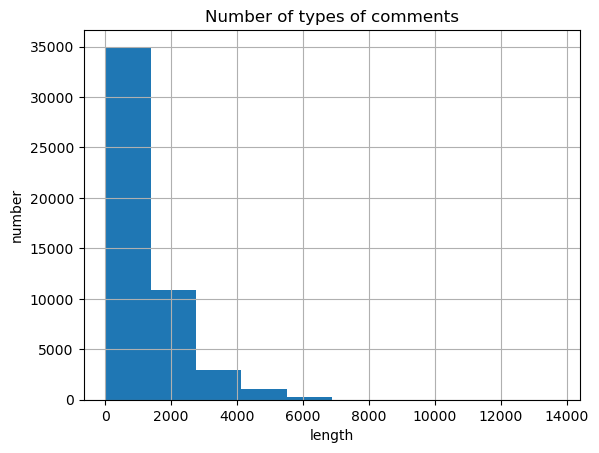

count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
dtype: float64


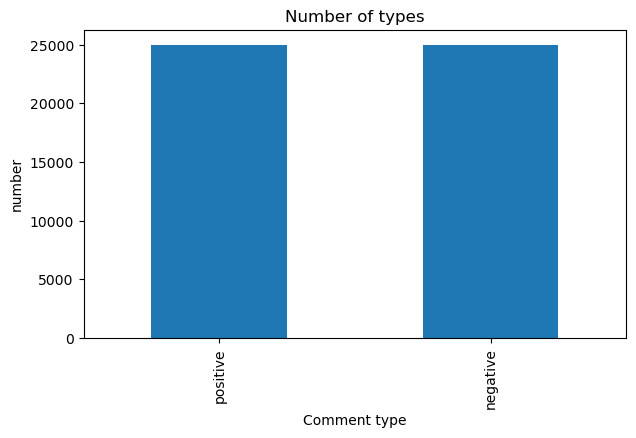

In [25]:
eda = EDA()
eda.get_length_dist(df['review'])
eda.get_class_dist(df)

In [37]:
def preprocess_text(text):
    # Remove HTML tags and strip whitespace
    text = re.sub(r'<[^>]*>', '', text)
    text = text.strip()
    # Remove noisy characters and extra spaces
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    # Lowercase text
    text = text.lower()
    # Tokenize text and remove stopwords
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

In [39]:
df['review'] = df['review'].apply(preprocess_text)

LookupError: 
**********************************************************************
  Resource 'punkt_tab' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'tokenizers/punkt_tab/english/'

  Searched in:
    - 'C:\\Users\\manan/nltk_data'
    - 'C:\\Users\\manan\\anaconda3\\nltk_data'
    - 'C:\\Users\\manan\\anaconda3\\share\\nltk_data'
    - 'C:\\Users\\manan\\anaconda3\\lib\\nltk_data'
    - 'C:\\Users\\manan\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [21]:
df['review'].head(20)

0     This is not a boring movie, the audience might...
1     To my eternal shame, I've never seen a silent ...
2     This movie is light, funny, and beautifully fi...
3     Despite the previous reviewer's screed, this i...
4     This is truly a kung fu classic. This film app...
5     I would have liked to put 0.5 but unfortunatel...
6     I have just finished watching this film for th...
7     A young cat tries to steal back his brothers s...
8     There are several ways to misunderstand this m...
9     Being an Elvis fan, I can't understand how thi...
10    Historical drama and coming of age story invol...
11    I passed this one on the shelf a few times, lo...
12    Well, how to start? I saw The Italian Job for ...
13    If you are a fan of early Duke movies, this Lo...
14    This will be best known for the Ferrari that w...
15    I had to get this movie, since it didn't come ...
16    The movie was actually a romantic drama based ...
17    I'd give this film a 1/10. This film is de

### Split x=feature, y=target

In [86]:
x = df['review']
y = df['sentiment']

In [88]:
from sklearn.preprocessing import LabelEncoder
label_encode = LabelEncoder()
Y = label_encode.fit_transform(df['sentiment'])
Y

array([1, 1, 0, ..., 0, 1, 0], shape=(50000,))

In [90]:
y

0        positive
1        positive
2        negative
3        positive
4        negative
           ...   
49995    positive
49996    positive
49997    negative
49998    positive
49999    negative
Name: sentiment, Length: 50000, dtype: object

### 0 represent negative comments and 1 represent positive comments

***

### Split the dataset into training and testing sets

In [92]:
xtrain, xtest, ytrain, ytest = train_test_split(x, Y, test_size=0.2, random_state=42)

### Create a vocabulary

In [33]:
from collections import Counter
word_counts = Counter(' '.join(xtrain).split())

### Display each word in the vocabulary along with its count

In [65]:
#for word, count in word_counts.items() :
    #print(f"{word}: {count}")

In [67]:
#vocab = [word for word, count in word_counts.most_common()]
#vocab

***

## Initialising Classifiers

In [74]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from timeit import default_timer as timer

In [96]:
svm_classifier = LinearSVC()
log_regression = LogisticRegression(max_iter=1000)
nb_classifier = MultinomialNB()
xgb_classifier = XGBClassifier()
random_forest_classifier = RandomForestClassifier(n_estimators=100, max_depth=3, max_features='sqrt', min_samples_leaf=4, bootstrap=True, n_jobs=-1, random_state=0)

In [98]:
def evaluate_model(model, xtest, ytest):
    # Make predictions using the model
    y_pred = model.predict(xtest)

    # Calculate accuracy
    accuracy = accuracy_score(ytest, y_pred)
    # Calculate precision
    precision = precision_score(ytest, y_pred)
    # Calculate recall
    recall = recall_score(ytest, y_pred)
    # Calculate f1 score
    f1 = f1_score(ytest, y_pred)
    # Generate a classification report and confusion matrix
    report = classification_report(ytest, y_pred)
    cm = confusion_matrix(ytest, y_pred)
    return y_pred, accuracy, precision, recall, f1, report, cm

In [100]:
batch_size = 1000

***

## 1. TF-IDF

### TF-IDF Vectorisation

In [104]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

#### Process the data in smaller batches for training data

In [106]:
start = timer()
tfidf_vectorizer_xtrain = []
for i in range(0, len(xtrain), batch_size):
    batch_X_train = xtrain[i:i + batch_size]
    batch_X_train_tfidf = tfidf_vectorizer.fit_transform(batch_X_train)
    tfidf_vectorizer_xtrain.extend(batch_X_train_tfidf.toarray())
print('Required time for embedding TFIDF with train data:- ', timer() - start) 

Required time for embedding TFIDF with train data:-  13.011556699988432


#### Repeat the same process for test data

In [170]:
start = timer()
tfidf_vectorizer_xtest = []
for i in range(0, len(xtest), batch_size):
    batch_X_test = xtest[i:i + batch_size]
    batch_X_test_tfidf = tfidf_vectorizer.transform(batch_X_test)
    tfidf_vectorizer_xtest.extend(batch_X_test_tfidf.toarray())
print('Required time for embedding TFIDF with train data:- ', timer() - start) 

Required time for embedding TFIDF with train data:-  2.2413124999729916


#### Fit classifiers

In [213]:
start = timer()
svm_tfidf = svm_classifier.fit(tfidf_vectorizer_xtrain, ytrain)
print('Required time for training Linear SVM classifiers:- ', timer() - start) 
start = timer()
lr_tfidf = log_regression.fit(tfidf_vectorizer_xtrain, ytrain)
print('Required time for training Logistic Regression classifiers:- ', timer() - start) 
start = timer()
nb_tfidf = nb_classifier.fit(tfidf_vectorizer_xtrain, ytrain)
print('Required time for training Naive Bayes classifiers:- ', timer() - start) 
start = timer()
xgboost_tfidf = xgb_classifier.fit(tfidf_vectorizer_xtrain, ytrain)
print('Required time for training XGBoost classifiers:- ', timer() - start) 
start = timer()
rfc_tfidf = random_forest_classifier.fit(tfidf_vectorizer_xtrain, ytrain)
print('Required time for training all five classifiers:- ', timer() - start) 

Required time for training Linear SVM classifiers:-  5.975355100003071
Required time for training Logistic Regression classifiers:-  4.602255899982993
Required time for training Naive Bayes classifiers:-  1.716338199970778
Required time for training XGBoost classifiers:-  80.13420430000406
Required time for training all five classifiers:-  11.067911899997853


### Linear SVM

In [215]:
start = timer()
y_pred_svm, accuracy_svm, precision_svm, recall_svm, f1_svm, report_svm, confusion_matrix_svm = evaluate_model(svm_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for SVM prediction:- ', timer() - start)

Required time for SVM prediction:-  0.3598505000118166


#### Actual vs. predicted results for LinearSVM

In [61]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_svm[:15]):
    print(f"Actual: {actual}, SVM Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 1, SVM Predicted: 1

Actual: 1, SVM Predicted: 1

Actual: 0, SVM Predicted: 0

Actual: 1, SVM Predicted: 0

Actual: 1, SVM Predicted: 1

Actual: 0, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 1, SVM Predicted: 1



In [63]:
print(f"LinearSVM Accuracy: {accuracy_svm:.2f}")
print(f"LinearSVM Precision: {precision_svm:.2f}")
print(f"LinearSVM Recall: {recall_svm:.2f}")
print(f"LinearSVM F1 score: {f1_svm:.2f}")
print("Classification Report:")
print(report_svm)
print("Confusion Matrix")
print(confusion_matrix_svm)

LinearSVM Accuracy: 0.70
LinearSVM Precision: 0.70
LinearSVM Recall: 0.69
LinearSVM F1 score: 0.70
Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.70      0.70      4938
           1       0.70      0.69      0.70      5062

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000

Confusion Matrix
[[3476 1462]
 [1585 3477]]


### Logistic Regression

In [219]:
start = timer()
y_pred_lr, accuracy_lr, precision_lr, recall_lr, f1_lr, report_lr, cm_lr = evaluate_model(lr_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for Logistic Regression prediction:- ', timer() - start) 

Required time for Logistic Regression prediction:-  0.3565737000317313


#### Actual vs. predicted results for Logistic Regression

In [71]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_lr[:15]):
    print(f"Actual: {actual}, Logistic Regression Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 0

Actual: 1, Logistic Regression Predicted: 1

Actual: 1, Logistic Regression Predicted: 1

Actual: 0, Logistic Regression Predicted: 0

Actual: 1, Logistic Regression Predicted: 0

Actual: 1, Logistic Regression Predicted: 1

Actual: 0, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 1

Actual: 1, Logistic Regression Predicted: 1



In [73]:
print(f"Logistic Regression Accuracy: {accuracy_lr:.2f}")
print(f"Logistic Regression Precision: {precision_lr:.2f}")
print(f"Logistic Regression Recall: {recall_lr:.2f}")
print(f"Logistic Regression F1 score: {f1_lr:.2f}")
print("Classification Report:")
print(report_lr)
print("Confusion Matrix")
print(cm_lr)

Logistic Regression Accuracy: 0.71
Logistic Regression Precision: 0.72
Logistic Regression Recall: 0.70
Logistic Regression F1 score: 0.71
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71      4938
           1       0.72      0.70      0.71      5062

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000

Confusion Matrix
[[3537 1401]
 [1540 3522]]


### Naive Bayes

In [75]:
start = timer()
y_pred_nb, accuracy_nb, precision_nb, recall_nb, f1_nb, report_nb, cm_nb = evaluate_model(nb_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for Naive Bayes prediction:- ', timer() - start) 

Required time for Naive Bayes prediction:-  0.28161229999386705


#### Actual vs. predicted results for Naive Bayes

In [77]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_nb[:15]):
    print(f"Actual: {actual}, Naive bayes Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 1

Actual: 0, Naive bayes Predicted: 0

Actual: 1, Naive bayes Predicted: 1

Actual: 1, Naive bayes Predicted: 1

Actual: 0, Naive bayes Predicted: 0

Actual: 1, Naive bayes Predicted: 0

Actual: 1, Naive bayes Predicted: 1

Actual: 0, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 0

Actual: 1, Naive bayes Predicted: 0



In [79]:
print(f"Naive bayes Accuracy: {accuracy_nb:.2f}")
print(f"Naive bayes Precision: {precision_nb:.2f}")
print(f"Naive bayes Recall: {recall_nb:.2f}")
print(f"Naive bayes F1 score: {f1_nb:.2f}")
print("Classification Report:")
print(report_nb)
print("Confusion Matrix:")
print(cm_nb)

Naive bayes Accuracy: 0.68
Naive bayes Precision: 0.75
Naive bayes Recall: 0.56
Naive bayes F1 score: 0.64
Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.80      0.71      4938
           1       0.75      0.56      0.64      5062

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.68     10000
weighted avg       0.70      0.68      0.68     10000

Confusion Matrix:
[[3966  972]
 [2204 2858]]


### XGBoost Classifier

In [223]:
start = timer()
y_pred_xgboost, accuracy_xgboost, precision_xgboost, recall_xgboost, f1_xgboost, report_xgboost, cm_xgboost = evaluate_model(xgboost_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for XGBoost classifier prediction:- ', timer() - start) 

Required time for XGBoost classifier prediction:-  0.31808739999542013


#### Actual vs. predicted results for XGBoost Classifier

In [83]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_xgboost[:15]):
    print(f"Actual: {actual}, XGBoost Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 1, XGBoost Predicted: 1

Actual: 1, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 1, XGBoost Predicted: 0

Actual: 1, XGBoost Predicted: 1

Actual: 0, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 1, XGBoost Predicted: 1



In [85]:
print(f"XGBoost Accuracy: {accuracy_xgboost:.2f}")
print(f"XGBoost Precision: {precision_xgboost:.2f}")
print(f"XGBoost Recall: {recall_xgboost:.2f}")
print(f"XGBoost F1 score: {f1_xgboost:.2f}")
print("Classification Report:")
print(report_xgboost)
print("Confusion Matrix:")
print(cm_xgboost)

XGBoost Accuracy: 0.69
XGBoost Precision: 0.70
XGBoost Recall: 0.69
XGBoost F1 score: 0.69
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.69      0.69      4938
           1       0.70      0.69      0.69      5062

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.69     10000
weighted avg       0.69      0.69      0.69     10000

Confusion Matrix:
[[3417 1521]
 [1590 3472]]


### Random Forest Classifier

In [227]:
start = timer()
y_pred_rfc, accuracy_rfc, precision_rfc, recall_rfc, f1_rfc, report_rfc, cm_rfc = evaluate_model(rfc_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for Random Forest classifier prediction:- ', timer() - start) 

Required time for Random Forest classifier prediction:-  0.3675023000105284


#### Actual vs. predicted results for Random Forest Classifier

In [89]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_rfc[:15]):
    print(f"Actual: {actual}, Random Forest Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 1, Random Forest Predicted: 1

Actual: 1, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 1, Random Forest Predicted: 1

Actual: 1, Random Forest Predicted: 1

Actual: 0, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 1

Actual: 1, Random Forest Predicted: 1



In [91]:
print(f"Random Forest Accuracy: {accuracy_rfc:.2f}")
print(f"Random Forest Precision: {precision_rfc:.2f}")
print(f"Random Forest Recall: {recall_rfc:.2f}")
print(f"Random Forest F1 score: {f1_rfc:.2f}")
print("Classification Report:")
print(report_rfc)
print("Confusion Matrix:")
print(cm_rfc)

Random Forest Accuracy: 0.61
Random Forest Precision: 0.66
Random Forest Recall: 0.46
Random Forest F1 score: 0.54
Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.76      0.66      4938
           1       0.66      0.46      0.54      5062

    accuracy                           0.61     10000
   macro avg       0.62      0.61      0.60     10000
weighted avg       0.62      0.61      0.60     10000

Confusion Matrix:
[[3757 1181]
 [2745 2317]]


#### Display all five models accuracy

In [93]:
model_names = ['LinearSVM', 'LogisticRegression', 'NaiveBayes', 'XGBoost', 'RandomForest']
model_accuracies = [accuracy_svm, accuracy_lr, accuracy_nb, accuracy_xgboost, accuracy_rfc]

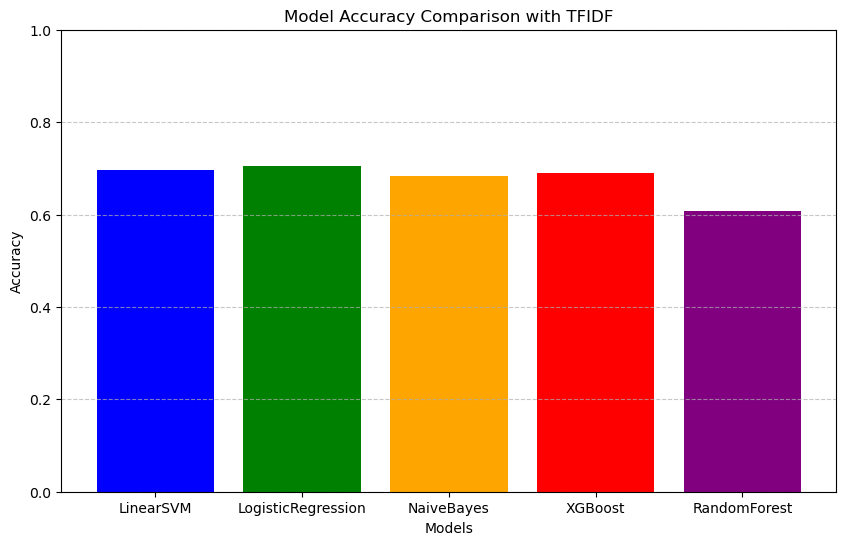

In [95]:
plt.figure(figsize=(10, 6))
plt.bar(model_names, model_accuracies, color=['blue', 'green', 'orange', 'red', 'purple'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison with TFIDF")
plt.ylim(0.0, 1.0)  # Set the y-axis limits
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

***

## 2. Universal Sentence Encoder (USE)

### Load the Universal Sentence Encoder model, and embed this model

In [76]:
start = timer()
embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")
print('Required time for upload USE from tensorflow hub:- ', timer() - start) 

Required time for upload USE from tensorflow hub:-  61.26299699995434


In [78]:
xtrain_use = []
xtest_use = []

In [108]:
start = timer()
for i in range(0, len(xtrain), batch_size):
    batch_X_train = xtrain[i:i + batch_size]
    batch_X_train_use = np.array(embed(batch_X_train))
    xtrain_use.extend(batch_X_train_use)
print('Required time for embedding xtrain with USE:- ', timer() - start)

Required time for embedding xtrain with USE:-  60.00538960000267


In [111]:
start = timer()
for i in range(0, len(xtest), batch_size):
    batch_X_test = xtest[i:i + batch_size]
    batch_X_test_use = np.array(embed(batch_X_test))
    xtest_use.extend(batch_X_test_use)
print('Required time for embedding xtest with USE:- ', timer() - start)

Required time for embedding xtest with USE:-  14.024612299981527


#### Fit classifiers

In [118]:
start = timer()
svm_use = svm_classifier.fit(xtrain_use, ytrain)
print('Required time for training Linear SVM classifier:- ', timer() - start) 
start = timer()
lr_use = log_regression.fit(xtrain_use, ytrain)
print('Required time for training Logistic Regression:- ', timer() - start)  
start = timer()
xgboost_use = xgb_classifier.fit(xtrain_use, ytrain)
print('Required time for training XGBoost classifier:- ', timer() - start) 
start = timer()
rfc_use = random_forest_classifier.fit(xtrain_use, ytrain)
print('Required time for training all Random Forest classifier:- ', timer() - start)

Required time for training Linear SVM classifier:-  10.900658399972599
Required time for training Logistic Regression:-  0.7360339000006206
Required time for training XGBoost classifier:-  16.702006199979223
Required time for training all Random Forest classifier:-  10.061725000035949


### Linear SVM

In [120]:
start = timer()
y_pred_svm_use, accuracy_svm_use, precision_svm_use, recall_svm_use, f1_svm_use, report_svm_use, cm_svm_use = evaluate_model(svm_use, xtest_use, ytest)
print('Required time for Linear SVM prediction with USE :- ', timer() - start) 

Required time for Linear SVM prediction with USE :-  0.07087049999972805


#### Actual vs. predicted results for LinearSVM with USE

In [123]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_svm_use[:15]):
    print(f"Actual: {actual}, SVM with USE embedding Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 1, SVM with USE embedding Predicted: 1

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 1, SVM with USE embedding Predicted: 1

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 1, SVM with USE embedding Predicted: 1

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 1, SVM with USE embedding Predicted: 1

Actual: 1, SVM with USE embedding Predicted: 0

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 1, SVM with USE embedding Predicted: 1

Actual: 1, SVM with USE embedding Predicted: 1

Actual: 1, SVM with USE embedding Predicted: 1



In [125]:
print(f"LinearSVM (USE) Accuracy: {accuracy_svm_use:.2f}")
print(f"LinearSVM (USE) Precision: {precision_svm_use:.2f}")
print(f"LinearSVM (USE) Recall: {recall_svm_use:.2f}")
print(f"LinearSVM (USE) F1 score: {f1_svm_use:.2f}")
print("Classification Report:")
print(report_svm_use)
print("Confusion Matrix")
print(cm_svm_use)

LinearSVM (USE) Accuracy: 0.87
LinearSVM (USE) Precision: 0.86
LinearSVM (USE) Recall: 0.87
LinearSVM (USE) F1 score: 0.87
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      5036
           1       0.86      0.87      0.87      4964

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000

Confusion Matrix
[[4358  678]
 [ 663 4301]]


### Logitic Regression

In [128]:
start = timer()
y_pred_lr_use, accuracy_lr_use, precision_lr_use, recall_lr_use, f1_lr_use, report_lr_use, cm_lr_use = evaluate_model(lr_use, xtest_use, ytest)
print('Required time for LR prediction with USE :- ', timer() - start) 

Required time for LR prediction with USE :-  0.07243110000854358


#### Actual vs. predicted results for Logistic Regression with USE

In [133]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_lr_use[:15]):
    print(f"Actual: {actual}, Logistic Regression Predicted with USE: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 1, Logistic Regression Predicted with USE: 1

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 1, Logistic Regression Predicted with USE: 1

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 1, Logistic Regression Predicted with USE: 1

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 1, Logistic Regression Predicted with USE: 1

Actual: 1, Logistic Regression Predicted with USE: 0

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 1, Logistic Regression Predicted with USE: 1

Actual: 1, Logistic Regression Predicted with USE: 1

Actual: 1, Logistic Regression Predicted with USE: 1



In [135]:
print(f"Logistic Regression (USE) Accuracy: {accuracy_lr_use:.2f}")
print(f"Logistic Regression (USE) Precision: {precision_lr_use:.2f}")
print(f"Logistic Regression (USE) Recall: {recall_lr_use:.2f}")
print(f"Logistic Regression (USE) F1 score: {f1_lr_use:.2f}")
print("Classification Report:")
print(report_lr_use)
print("Confusion Matrix")
print(cm_lr_use)

Logistic Regression (USE) Accuracy: 0.86
Logistic Regression (USE) Precision: 0.86
Logistic Regression (USE) Recall: 0.86
Logistic Regression (USE) F1 score: 0.86
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      5036
           1       0.86      0.86      0.86      4964

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000

Confusion Matrix
[[4344  692]
 [ 696 4268]]


### XGBoost Classifier

In [139]:
start = timer()
y_pred_xgboost_use, accuracy_xgboost_use, precision_xgboost_use, recall_xgboost_use, f1_xgboost_use, report_xgboost_use, cm_xgboost_use = evaluate_model(xgboost_use, xtest_use, ytest)
print('Required time for XGBoost classifier prediction with USE:- ', timer() - start) 

Required time for XGBoost classifier prediction with USE:-  0.0590119999833405


#### Actual vs. predicted results for XGBooost classifier with USE

In [141]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_xgboost_use[:15]):
    print(f"Actual: {actual}, XGBoost with USE Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 1, XGBoost with USE Predicted: 1

Actual: 0, XGBoost with USE Predicted: 0

Actual: 1, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 0

Actual: 1, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 0

Actual: 1, XGBoost with USE Predicted: 1

Actual: 1, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 0

Actual: 1, XGBoost with USE Predicted: 1

Actual: 1, XGBoost with USE Predicted: 1

Actual: 1, XGBoost with USE Predicted: 1



In [143]:
print(f"XGBoost (USE) Accuracy: {accuracy_xgboost_use:.2f}")
print(f"XGBoost (USE) Precision: {precision_xgboost_use:.2f}")
print(f"XGBoost (USE) Recall: {recall_xgboost_use:.2f}")
print(f"XGBoost (USE) F1 score: {f1_xgboost_use:.2f}")
print("Classification Report:")
print(report_xgboost_use)
print("Confusion Matrix:")
print(cm_xgboost_use)

XGBoost (USE) Accuracy: 0.86
XGBoost (USE) Precision: 0.85
XGBoost (USE) Recall: 0.86
XGBoost (USE) F1 score: 0.85
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      5036
           1       0.85      0.86      0.85      4964

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000

Confusion Matrix:
[[4304  732]
 [ 714 4250]]


### Random Forest Classifier

In [146]:
start = timer()
y_pred_rfc_use, accuracy_rfc_use, precision_rfc_use, recall_rfc_use, f1_rfc_use, report_rfc_use, cm_rfc_use = evaluate_model(rfc_use, xtest_use, ytest)
print('Required time for Random Forest classifier with USE prediction:- ', timer() - start) 

Required time for Random Forest classifier with USE prediction:-  0.10576100001344457


#### Actual vs. predicted results for Random Forest classifier with USE

In [149]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_rfc_use[:15]):
    print(f"Actual: {actual}, Random Forest with USE Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 1, Random Forest with USE Predicted: 1

Actual: 0, Random Forest with USE Predicted: 0

Actual: 1, Random Forest with USE Predicted: 1

Actual: 0, Random Forest with USE Predicted: 0

Actual: 0, Random Forest with USE Predicted: 0

Actual: 1, Random Forest with USE Predicted: 1

Actual: 0, Random Forest with USE Predicted: 0

Actual: 1, Random Forest with USE Predicted: 1

Actual: 1, Random Forest with USE Predicted: 0

Actual: 0, Random Forest with USE Predicted: 0

Actual: 0, Random Forest with USE Predicted: 0

Actual: 0, Random Forest with USE Predicted: 1

Actual: 1, Random Forest with USE Predicted: 1

Actual: 1, Random Forest with USE Predicted: 1

Actual: 1, Random Forest with USE Predicted: 1



In [151]:
print(f"Random Forest (USE) Accuracy: {accuracy_rfc_use:.2f}")
print(f"Random Forest (USE) Precision: {precision_rfc_use:.2f}")
print(f"Random Forest (USE) Recall: {recall_rfc_use:.2f}")
print(f"Random Forest (USE) F1 score: {f1_rfc_use:.2f}")
print("Classification Report:")
print(report_rfc_use)
print("Confusion Matrix:")
print(cm_rfc_use)

Random Forest (USE) Accuracy: 0.81
Random Forest (USE) Precision: 0.81
Random Forest (USE) Recall: 0.82
Random Forest (USE) F1 score: 0.81
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      5036
           1       0.81      0.82      0.81      4964

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000

Confusion Matrix:
[[4083  953]
 [ 901 4063]]


#### Display all four models accuracy

In [154]:
model_names = ['LinearSVM', 'LogisticRegression', 'XGBoost', 'RandomForest']
model_accuracies = [accuracy_svm_use, accuracy_lr_use, accuracy_xgboost_use, accuracy_rfc_use]

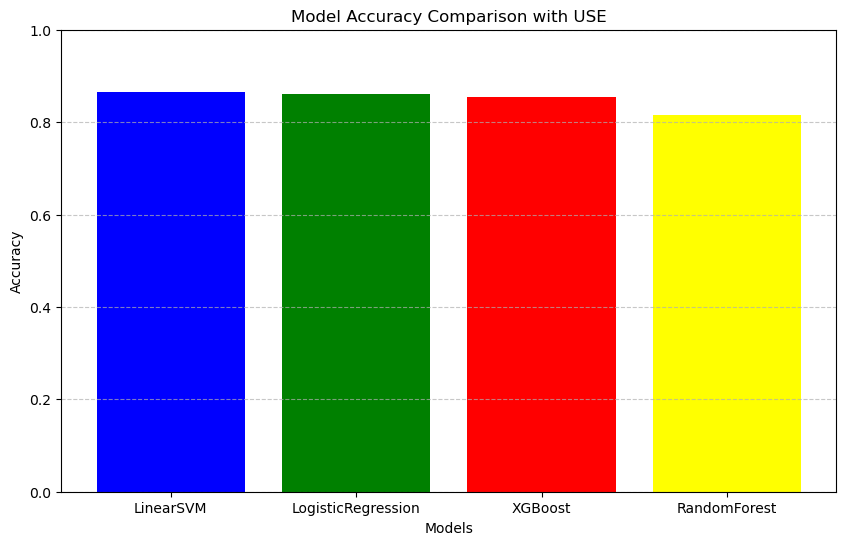

In [160]:
plt.figure(figsize=(10, 6))
plt.bar(model_names, model_accuracies, color=['blue', 'green', 'red', 'yellow'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison with USE")
plt.ylim(0.0, 1.0)  # Set the y-axis limits
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

***

## 3. TF-IDF + Universal Sentence Encoder (USE)

### Combine TF-IDF and Universal Sentence Encoder embeddings

In [172]:
xtrain_tfidf_use_combined = tf.concat([tfidf_vectorizer_xtrain, xtrain_use], axis=1)
xtest_tfidf_use_combined = tf.concat([tfidf_vectorizer_xtest, xtest_use], axis=1)

#### Fit classifiers 

In [174]:
start = timer()
svm_tfidf_use = svm_classifier.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training Linear SVM:- ', timer() - start) 
start = timer()
lr_tfidf_use = log_regression.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training Logistic Regression:- ', timer() - start)
start = timer()
xgboost_tfidf_use = xgb_classifier.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training XGBoost classifier:- ', timer() - start)
start = timer()
rfc_tfidf_use = random_forest_classifier.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training Random Forest classifier:- ', timer() - start)

Required time for training Linear SVM:-  15.852503500005696
Required time for training Logistic Regression:-  7.094487900030799
Required time for training XGBoost classifier:-  125.99362719996134
Required time for training Random Forest classifier:-  18.117978500027675


### Linear SVM

In [177]:
start = timer()
y_pred_svm_tfidf_use, accuracy_svm_tfidf_use, precision_svm_tfidf_use, recall_svm_tfidf_use, f1_svm_tfidf_use, report_svm_tfidf_use, cm_svm_tfidf_use = evaluate_model(svm_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for Linear SVM prediction with TFIDF+USE :- ', timer() - start) 

Required time for Linear SVM prediction with TFIDF+USE :-  0.18282640003599226


#### Actual vs. predicted results for Linear SVM with TFIDF + USE

In [180]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_svm_tfidf_use[:15]):
    print(f"Actual: {actual}, SVM with TFIDF+USE Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 1, SVM with TFIDF+USE Predicted: 1

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 1, SVM with TFIDF+USE Predicted: 1

Actual: 0, SVM with TFIDF+USE Predicted: 1

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 1, SVM with TFIDF+USE Predicted: 1

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 1, SVM with TFIDF+USE Predicted: 1

Actual: 1, SVM with TFIDF+USE Predicted: 0

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 1, SVM with TFIDF+USE Predicted: 1

Actual: 1, SVM with TFIDF+USE Predicted: 1

Actual: 1, SVM with TFIDF+USE Predicted: 1



In [182]:
print(f"LinearSVM (TFIDF+USE) Accuracy: {accuracy_svm_tfidf_use:.2f}")
print(f"LinearSVM (TFIDF+USE) Precision: {precision_svm_tfidf_use:.2f}")
print(f"LinearSVM (TFIDF+USE) Recall: {recall_svm_tfidf_use:.2f}")
print(f"LinearSVM (TFIDF+USE) F1 score: {f1_svm_tfidf_use:.2f}")
print("Classification Report:")
print(report_svm_tfidf_use)
print("Confusion Matrix")
print(cm_svm_tfidf_use)

LinearSVM (TFIDF+USE) Accuracy: 0.84
LinearSVM (TFIDF+USE) Precision: 0.83
LinearSVM (TFIDF+USE) Recall: 0.87
LinearSVM (TFIDF+USE) F1 score: 0.85
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      5036
           1       0.83      0.87      0.85      4964

    accuracy                           0.84     10000
   macro avg       0.85      0.85      0.84     10000
weighted avg       0.85      0.84      0.84     10000

Confusion Matrix
[[4147  889]
 [ 661 4303]]


### Logistic Regression

In [185]:
start = timer()
y_pred_lr_tfidf_use, accuracy_lr_tfidf_use, precision_lr_tfidf_use, recall_lr_tfidf_use, f1_lr_tfidf_use, report_lr_tfidf_use, cm_lr_tfidf_use = evaluate_model(lr_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for Logistic Regression prediction with TFIDF+USE :- ', timer() - start) 

Required time for Logistic Regression prediction with TFIDF+USE :-  0.15353839995805174


####  Actual vs. predicted results for Logistic Regression with TFIDF + USE

In [187]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_lr_tfidf_use[:15]):
    print(f"Actual: {actual}, LR with TFIDF+USE embedding Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 1, LR with TFIDF+USE embedding Predicted: 1

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 1, LR with TFIDF+USE embedding Predicted: 1

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 1, LR with TFIDF+USE embedding Predicted: 1

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 1, LR with TFIDF+USE embedding Predicted: 1

Actual: 1, LR with TFIDF+USE embedding Predicted: 0

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 1, LR with TFIDF+USE embedding Predicted: 1

Actual: 1, LR with TFIDF+USE embedding Predicted: 1

Actual: 1, LR with TFIDF+USE embedding Predicted: 1



In [189]:
print(f"Logistic Regression (TFIDF+USE) Accuracy: {accuracy_lr_tfidf_use:.2f}")
print(f"Logistic Regression (TFIDF+USE) Precision: {precision_lr_tfidf_use:.2f}")
print(f"Logistic Regression (TFIDF+USE) Recall: {recall_lr_tfidf_use:.2f}")
print(f"Logistic Regression (TFIDF+USE) F1 score: {f1_lr_tfidf_use:.2f}")
print("Classification Report:")
print(report_lr_tfidf_use)
print("Confusion Matrix")
print(cm_lr_tfidf_use)

Logistic Regression (TFIDF+USE) Accuracy: 0.87
Logistic Regression (TFIDF+USE) Precision: 0.85
Logistic Regression (TFIDF+USE) Recall: 0.88
Logistic Regression (TFIDF+USE) F1 score: 0.87
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.85      0.86      5036
           1       0.85      0.88      0.87      4964

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000

Confusion Matrix
[[4290  746]
 [ 598 4366]]


### XGBoost Classifier

In [193]:
start = timer()
y_pred_xgb_tfidf_use, accuracy_xgb_tfidf_use, precision_xgb_tfidf_use, recall_xgb_tfidf_use, f1_xgb_tfidf_use, report_xgb_tfidf_use, cm_xgb_tfidf_use = evaluate_model(xgboost_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for XGBoost prediction with TFIDF+USE :- ', timer() - start) 

Required time for XGBoost prediction with TFIDF+USE :-  0.9429154999670573


#### Actual vs. predicted results for XGBoost with TFIDF + USE

In [195]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_xgb_tfidf_use[:15]):
    print(f"Actual: {actual}, XGBoost with TFIDF+USE embedding Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 1, XGBoost with TFIDF+USE embedding Predicted: 1

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 1, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 1, XGBoost with TFIDF+USE embedding Predicted: 1

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 1, XGBoost with TFIDF+USE embedding Predicted: 1

Actual: 1, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 1, XGBoost with TFIDF+USE embedding Predicted: 1

Actual: 1, XGBoost with TFIDF+USE embedding Predicted: 1

Actual: 1, XGBoost with TFIDF+USE embedding Predicted: 1



In [197]:
print(f"XGBoost (TFIDF+USE) Accuracy: {accuracy_xgb_tfidf_use:.2f}")
print(f"XGBoost (TFIDF+USE) Precision: {precision_xgb_tfidf_use:.2f}")
print(f"XGBoost (TFIDF+USE) Recall: {recall_xgb_tfidf_use:.2f}")
print(f"XGBoost (TFIDF+USE) F1 score: {f1_xgb_tfidf_use:.2f}")
print("Classification Report:")
print(report_xgb_tfidf_use)
print("Confusion Matrix:")
print(cm_xgb_tfidf_use)

XGBoost (TFIDF+USE) Accuracy: 0.85
XGBoost (TFIDF+USE) Precision: 0.85
XGBoost (TFIDF+USE) Recall: 0.86
XGBoost (TFIDF+USE) F1 score: 0.85
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      5036
           1       0.85      0.86      0.85      4964

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

Confusion Matrix:
[[4273  763]
 [ 712 4252]]


### Random Forest classifier

In [201]:
start = timer()
y_pred_rfc_tfidf_use, accuracy_rfc_tfidf_use, precision_rfc_tfidf_use, recall_rfc_tfidf_use, f1_rfc_tfidf_use, report_rfc_tfidf_use, cm_rfc_tfidf_use = evaluate_model(rfc_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for Random Forest prediction with TFIDF+USE :- ', timer() - start) 

Required time for Random Forest prediction with TFIDF+USE :-  0.311860500019975


#### Actual vs. predicted results for Random Forest with TFIDF + USE

In [203]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_rfc_tfidf_use[:15]):
    print(f"Actual: {actual}, RFC with TFIDF+USE embedding Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 1, RFC with TFIDF+USE embedding Predicted: 1

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 1, RFC with TFIDF+USE embedding Predicted: 1

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 1, RFC with TFIDF+USE embedding Predicted: 1

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 1, RFC with TFIDF+USE embedding Predicted: 1

Actual: 1, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 1, RFC with TFIDF+USE embedding Predicted: 1

Actual: 1, RFC with TFIDF+USE embedding Predicted: 1

Actual: 1, RFC with TFIDF+USE embedding Predicted: 1



In [205]:
print(f"Random Forest (TFIDF+USE) Accuracy: {accuracy_rfc_tfidf_use:.2f}")
print(f"Random Forest (TFIDF+USE) Precision: {precision_rfc_tfidf_use:.2f}")
print(f"Random Forest (TFIDF+USE) Recall: {recall_rfc_tfidf_use:.2f}")
print(f"Random Forest (TFIDF+USE) F1 score: {f1_rfc_tfidf_use:.2f}")
print("Classification Report:")
print(report_rfc_tfidf_use)
print("Confusion Matrix:")
print(cm_rfc_tfidf_use)

Random Forest (TFIDF+USE) Accuracy: 0.81
Random Forest (TFIDF+USE) Precision: 0.80
Random Forest (TFIDF+USE) Recall: 0.83
Random Forest (TFIDF+USE) F1 score: 0.81
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      5036
           1       0.80      0.83      0.81      4964

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000

Confusion Matrix:
[[4036 1000]
 [ 865 4099]]


### Visualisation

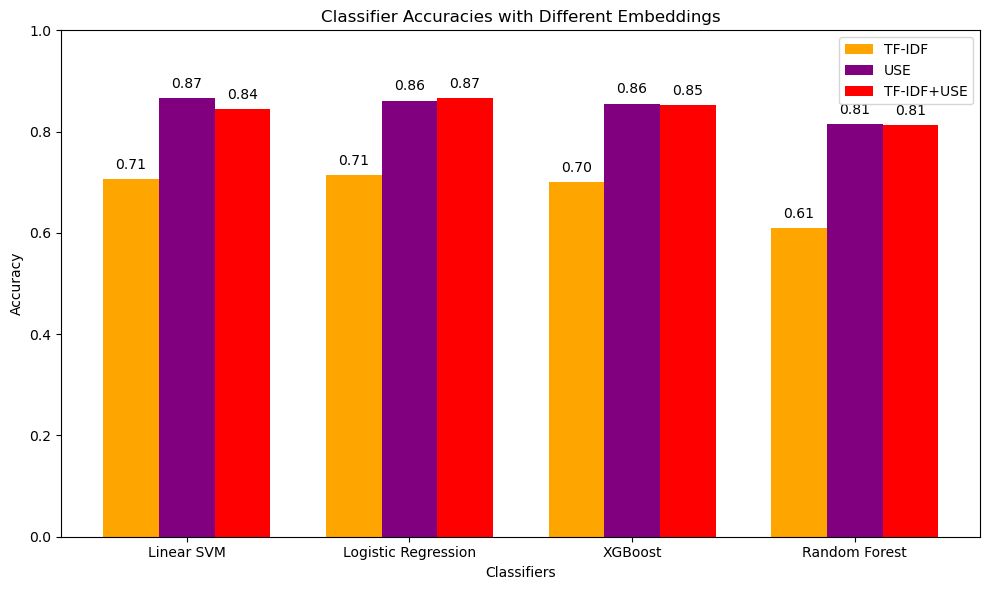

In [229]:
# Define the classifiers and their corresponding accuracies
classifiers = ["Linear SVM", "Logistic Regression", "XGBoost", "Random Forest"]
tfidf_accuracies = [accuracy_svm, accuracy_lr, accuracy_xgboost, accuracy_rfc]  # Replace with actual accuracy values
use_accuracies = [accuracy_svm_use, accuracy_lr_use, accuracy_xgboost_use, accuracy_rfc_use]  # Replace with actual accuracy values
tfidf_use_accuracies = [accuracy_svm_tfidf_use, accuracy_lr_tfidf_use, accuracy_xgb_tfidf_use, accuracy_rfc_tfidf_use]  # Replace with actual accuracy values

# Create an index for the x-axis
x = np.arange(len(classifiers))

# Set the width of the bars
bar_width = 0.25

# Create a grouped bar chart
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width, tfidf_accuracies, bar_width, label='TF-IDF', color='orange')
plt.bar(x, use_accuracies, bar_width, label='USE', color='purple')
plt.bar(x + bar_width, tfidf_use_accuracies, bar_width, label='TF-IDF+USE', color='red')

# Set labels, title, and legend
plt.xlabel('Classifiers')
plt.ylabel('Accuracy')
plt.title('Classifier Accuracies with Different Embeddings')
plt.xticks(x, classifiers)
plt.ylim(0, 1.0)
plt.legend()

# Add accuracy values on top of the bars
for i in range(len(classifiers)):
    plt.text(x[i] - bar_width, tfidf_accuracies[i] + 0.02, f"{tfidf_accuracies[i]:.2f}", ha='center')
    plt.text(x[i], use_accuracies[i] + 0.02, f"{use_accuracies[i]:.2f}", ha='center')
    plt.text(x[i] + bar_width, tfidf_use_accuracies[i] + 0.02, f"{tfidf_use_accuracies[i]:.2f}", ha='center')


# Display the plot
plt.tight_layout()
plt.show()

## Conclusion:

The above visulisation showse the mbeddings works better for sentiment analysis on IMDB dataset with different classifiers